# Combining Asteroseismology and Gaia constraints

Gaia astrometry and photometry can constrain distance, luminosity, colour, and therefore radius and temperature. This tutorial demonstrates parallax, G-band magnitude, and BP–RP colour in combination with $\nu_{\max}$ and $\Delta\nu$.

> **Caution:** AsteroScale's Gaia bolometric corrections are deliberately rough, near-solar placeholders. These examples demonstrate the inference interface; do not use them for precision Gaia photometry or final stellar parameters.

In [11]:
import asteroscale as ast
solver = ast.Solver(preset="fast")

## Parallax and apparent G magnitude

In this simplified model, Gaia-like data mainly constrain luminosity, temperature, and therefore radius; they do not strongly determine mass by themselves. Extinction is partly degenerate with temperature and luminosity, so an external extinction estimate is valuable. If `A_G` is omitted, AsteroScale marginalizes over its broad default prior.

param             mean         std         p16         p50         p84
----------------------------------------------------------------------
M               0.9749       0.553      0.5581      0.7752       1.408
R                1.071      0.1115      0.9806       1.042        1.16


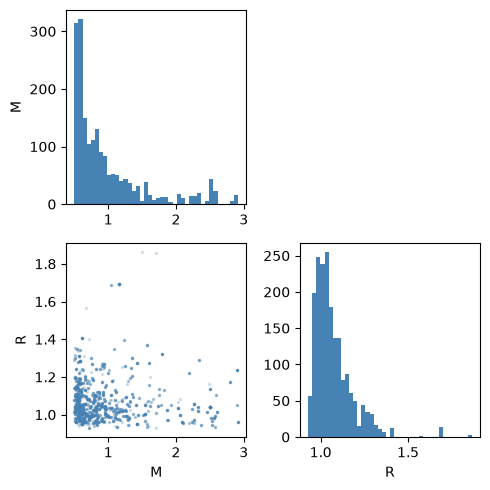

In [ ]:
given = {"plx": (10.0, 0.1),
         "G_mag": (9.90, 0.02),
         "BP_RP": (0.82, 0.02),
         }
samples = solver.solve(given, want=["M", "R"])
ast.summarize(samples)
fig = ast.plot_posterior(samples)

The seismic measurements constrain mass and radius through the scaling relations, but without temperature or luminosity information their posterior can remain broad and prior-sensitive.

/home/ADF/nielsemb/work/repos/AsteroScale/asteroscale/solver.py:786: UserWarning: dnu is partly outside calibration: 46.0% of evaluated samples are within the adopted domain (0.8 <= M/Msun <= 2.0, -1.0 <= [Fe/H] <= 0.5, 3800 <= Teff/K <= 7000, numax >= 6 microhertz; main sequence to slightly beyond the RGB bump).
  report = self._store_solution(


param             mean         std         p16         p50         p84
----------------------------------------------------------------------
M               0.7996       0.197      0.5748      0.7564        1.03
R               0.9053     0.08149      0.8074      0.8991      0.9998


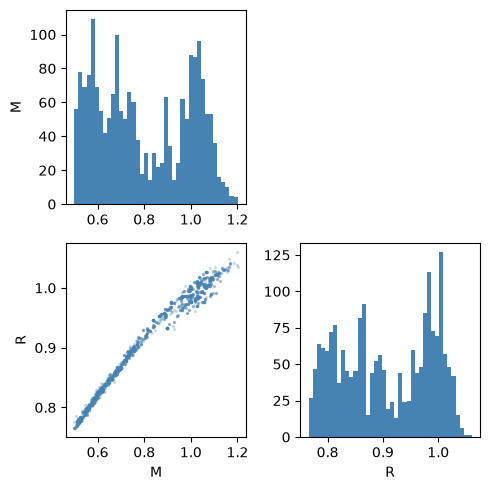

In [17]:
given = {"numax": (3090, 30),
         "dnu": (135.1, 1.0),
         }
samples = solver.solve(given, want=["M", "R"])
ast.summarize(samples)
fig = ast.plot_posterior(samples)

Combining the complementary constraints can narrow the mass-radius solution. A narrow result here demonstrates the interface, not precision validation of the placeholder Gaia corrections.

param             mean         std         p16         p50         p84
----------------------------------------------------------------------
M               0.9831     0.03965        0.94      0.9829       1.023
R               0.9935     0.01604      0.9764      0.9931       1.009


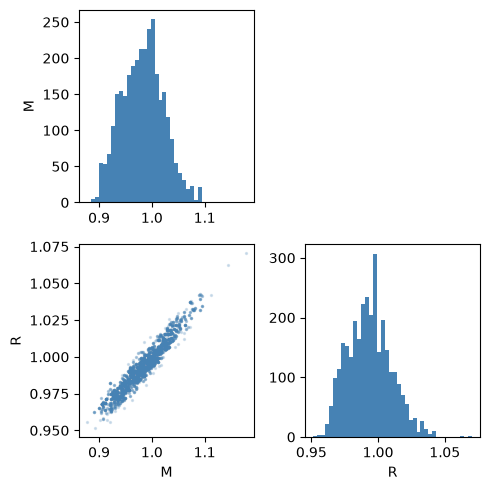

In [19]:
given = {"numax": (3090, 30),
         "dnu": (135.1, 1.0),
         "plx": (10.0, 0.1),
         "G_mag": (9.90, 0.02),
         "BP_RP": (0.82, 0.02),
         }
samples = solver.solve(given, want=["M", "R"])
ast.summarize(samples)
fig = ast.plot_posterior(samples)

A precision implementation would replace these placeholder relations with a validated bolometric-correction grid and use an external extinction constraint or dust-map prior.